# 09-1. Preprocessing v2 (EDA 검증 반영)

## 09 대비 변경점
| 검증 결과 | 문제 | 09-1 개선 |
|-----------|------|----------|
| Spike 감지 | lactate/ph/bilirubin 55%+ spike | spike는 missing flag이 구분 → **`ph_missing` 플래그 추가** |
| Event/Non-event 분포 | global median fill → gap 희석 | **환자 median cascade** 로 분포 보존 |
| MNAR 검증 | flag ↔ outcome 연관 확인 | Missing flag 5개로 확대 (ph_missing 추가) |
| FFill Leakage | groupby(stay_id) 정상 | 동일 유지 |

## 핵심 변경
1. **`ph_missing` 플래그 추가** — 09에서는 `abga_checked`에 묶여있던 ph 결측 정보를 독립 분리
2. **환자 median cascade** — global median 직행 대신 환자별 median 우선 사용
3. **값은 전부 fill** — NaN 없이 깔끔하게, flag이 "imputed vs 실측" 구분 담당

## 전처리 전략 (v2)
| 피처 | 결측률 | 전략 | vs 09 |
|------|--------|------|-------|
| Vitals | 1~3% | FFill → BFill → Median | 동일 |
| Temp | 3.4% | FFill(6) → **환자 median** → 36.8 | cascade 추가 |
| Labs (일반) | 7~8% | FFill → **환자 median** → Global median | cascade 추가 |
| Lactate | 63% | FFill(12) → **환자 median** → 1.2 + Flag | cascade 추가 |
| pH | 62% | FFill(12) → **환자 median** → 7.40 + **ph_missing** | **flag 신규** |
| Bilirubin | 62% | FFill(24) → **환자 median** → Global median + Flag | cascade 추가 |
| GCS | 9~10% | FFill → BFill → Median | 동일 |
| Urine | 18% | FFill → BFill → **환자 median** → Global median + Flag | cascade 추가 |

## Missing Flag (5개)
| Flag | 대상 | 의미 |
|------|------|------|
| `lactate_missing` | lactate | 젖산 미측정 = 경증 |
| `abga_checked` | ph + sao2 | ABGA 시행 = 중증 의심 |
| **`ph_missing`** | ph | **pH 미측정 (독립 flag)** |
| `bilirubin_missing` | bilirubin | 간기능 미검사 = 경증 |
| `urine_missing` | urine | 소변 미모니터링 = 경증 |

## 입출력
- 입력: `sliding_window_merged.csv`
- 출력: `preprocessed_v2.csv`

In [1]:
from pathlib import Path
DATA_DIR = Path("../data")
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

INPUT_DIR = PROCESSED_DIR
OUTPUT_DIR = PROCESSED_DIR

print('=== 09-1. Preprocessing v2 (EDA 검증 반영) ===')

=== 09-1. Preprocessing v2 (EDA 검증 반영) ===


## Step 1: 데이터 로드

In [2]:
print('Step 1: 데이터 로드')

df = pd.read_csv(
    INPUT_DIR / "sliding_window_merged.csv",
    parse_dates=['observation_start', 'observation_end']
)
print(f'rows: {len(df):,}, cols: {len(df.columns)}')
print(f'환자: {df["stay_id"].nunique():,}명')

# 환자별, 시간순 정렬 (FFill 전 필수)
df = df.sort_values(['stay_id', 'observation_hour']).reset_index(drop=True)

# 원본 결측 상태 보존 (검증용)
raw_missing = df.isnull().sum()
print(f'\n정렬 완료')

Step 1: 데이터 로드
rows: 158,985, cols: 54
환자: 4,713명

정렬 완료


In [3]:
# 피처 컬럼 정의
vital_cols = ['hr', 'rr', 'spo2', 'sbp', 'dbp', 'mbp']
vital_stat_cols = ['hr_max', 'rr_max', 'spo2_min', 'sbp_min']
lab_cols = ['creatinine', 'wbc', 'platelets', 'potassium', 'sodium']
high_missing_labs = ['lactate', 'ph', 'bilirubin']  # 60%+ 결측 → cascade fill + flag
gcs_cols = ['gcs_eye', 'gcs_verbal', 'gcs_motor', 'gcs_total']
urine_cols = ['urine_ml_6h', 'urine_ml_kg_hr_avg', 'oliguria_flag']

drop_cols = ['sao2']  # 93% 결측 + spo2 중복

print('피처 그룹:')
print(f'  Vitals ({len(vital_cols)}): {vital_cols}')
print(f'  Vital Stats ({len(vital_stat_cols)}): {vital_stat_cols}')
print(f'  Labs ({len(lab_cols)}): {lab_cols}')
print(f'  High-missing Labs ({len(high_missing_labs)}): {high_missing_labs} → cascade fill + flag')
print(f'  GCS ({len(gcs_cols)}): {gcs_cols}')
print(f'  Urine ({len(urine_cols)}): {urine_cols}')
print(f'  Drop: {drop_cols}')

피처 그룹:
  Vitals (6): ['hr', 'rr', 'spo2', 'sbp', 'dbp', 'mbp']
  Vital Stats (4): ['hr_max', 'rr_max', 'spo2_min', 'sbp_min']
  Labs (5): ['creatinine', 'wbc', 'platelets', 'potassium', 'sodium']
  High-missing Labs (3): ['lactate', 'ph', 'bilirubin'] → cascade fill + flag
  GCS (4): ['gcs_eye', 'gcs_verbal', 'gcs_motor', 'gcs_total']
  Urine (3): ['urine_ml_6h', 'urine_ml_kg_hr_avg', 'oliguria_flag']
  Drop: ['sao2']


In [4]:
# 결측치 현황 (처리 전)
print('=== 결측률 (처리 전) ===')

all_feature_cols = vital_cols + ['temp'] + vital_stat_cols + lab_cols + high_missing_labs + gcs_cols + urine_cols

for col in all_feature_cols:
    if col in df.columns:
        rate = df[col].isna().mean() * 100
        print(f'  {col:<22} {rate:>5.1f}%')

=== 결측률 (처리 전) ===
  hr                       0.6%
  rr                       1.2%
  spo2                     0.8%
  sbp                      1.3%
  dbp                      1.3%
  mbp                      1.4%
  temp                     3.4%
  hr_max                   0.6%
  rr_max                   1.2%
  spo2_min                 0.8%
  sbp_min                  1.3%
  creatinine               6.6%
  wbc                      8.2%
  platelets                8.1%
  potassium                6.6%
  sodium                   6.7%
  lactate                 62.9%
  ph                      61.8%
  bilirubin               61.7%
  gcs_eye                  9.5%
  gcs_verbal               9.7%
  gcs_motor                9.9%
  gcs_total                9.4%
  urine_ml_6h             17.9%
  urine_ml_kg_hr_avg      17.9%
  oliguria_flag           17.9%


## Step 2: Missing Flag 생성 & sao2 드랍

> **변경**: `ph_missing` 플래그 추가 (09에서는 `abga_checked`에 묶여 있었음)  
> ph 결측 여부를 독립 flag으로 분리 → 모델이 "ph imputed" 를 직접 학습 가능

In [5]:
print('Step 2: Missing Flag 생성 & sao2 드랍')

# abga_checked (ph or sao2 측정 여부) — 09와 동일
ph_measured = df['ph'].notna() if 'ph' in df.columns else pd.Series(False, index=df.index)
sao2_measured = df['sao2'].notna() if 'sao2' in df.columns else pd.Series(False, index=df.index)
df['abga_checked'] = (ph_measured | sao2_measured).astype(int)
print(f'  abga_checked: {df["abga_checked"].sum():,}건 ({df["abga_checked"].mean()*100:.1f}%)')

# ph_missing (NEW) — ph 결측 독립 flag
df['ph_missing'] = df['ph'].isna().astype(int) if 'ph' in df.columns else 1
print(f'  ph_missing: 측정={(df["ph_missing"]==0).sum():,}, 미측정={(df["ph_missing"]==1).sum():,} ← NEW')

# lactate_missing
df['lactate_missing'] = df['lactate'].isna().astype(int) if 'lactate' in df.columns else 1
print(f'  lactate_missing: 측정={(df["lactate_missing"]==0).sum():,}, 미측정={(df["lactate_missing"]==1).sum():,}')

# bilirubin_missing
df['bilirubin_missing'] = df['bilirubin'].isna().astype(int) if 'bilirubin' in df.columns else 1
print(f'  bilirubin_missing: 측정={(df["bilirubin_missing"]==0).sum():,}, 미측정={(df["bilirubin_missing"]==1).sum():,}')

# urine_missing
urine_any_na = df[['urine_ml_6h', 'urine_ml_kg_hr_avg']].isna().all(axis=1)
df['urine_missing'] = urine_any_na.astype(int)
print(f'  urine_missing: 모니터링={(df["urine_missing"]==0).sum():,}, 미모니터링={(df["urine_missing"]==1).sum():,}')

# sao2 드랍
for col in drop_cols:
    if col in df.columns:
        df = df.drop(columns=[col])
        print(f'  {col} 드랍')

print(f'\nFlag 총 5개: abga_checked, ph_missing(NEW), lactate_missing, bilirubin_missing, urine_missing')
print(f'현재 컬럼: {len(df.columns)}개')

Step 2: Missing Flag 생성 & sao2 드랍
  abga_checked: 61,459건 (38.7%)
  ph_missing: 측정=60,789, 미측정=98,196 ← NEW
  lactate_missing: 측정=59,045, 미측정=99,940
  bilirubin_missing: 측정=60,888, 미측정=98,097
  urine_missing: 모니터링=130,541, 미모니터링=28,444
  sao2 드랍

Flag 총 5개: abga_checked, ph_missing(NEW), lactate_missing, bilirubin_missing, urine_missing
현재 컬럼: 58개


## Step 3: Vital Signs (1~3% 결측)

> **변경 없음**: 결측률 낮아 spike 이슈 없음. FFill → BFill → Median.

In [6]:
print('Step 3: Vital Signs')

# HR, RR, SpO2, SBP, DBP, MBP — FFill → BFill → Median
for col in vital_cols:
    if col not in df.columns:
        continue
    before = df[col].isna().sum()
    df[col] = df.groupby('stay_id')[col].ffill().bfill()
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f'  {col}: {before:,} → 0')

Step 3: Vital Signs
  hr: 964 → 0
  rr: 1,882 → 0
  spo2: 1,285 → 0
  sbp: 2,047 → 0
  dbp: 2,050 → 0
  mbp: 2,180 → 0


## Step 4: Temp (3.4% 결측)

> **변경**: 09에서 `FFill(6) → 36.8` → spike at 36.8 (1%이긴 하지만)  
> **09-1**: `FFill(6) → 환자 median → 36.8` cascade로 개인차 반영

In [7]:
print('Step 4: Temp (cascade imputation)')

col = 'temp'
if col in df.columns:
    before = df[col].isna().sum()
    
    # 1) FFill(limit=6) — 환자 내
    df[col] = df.groupby('stay_id')[col].ffill(limit=6)
    after_ffill = df[col].isna().sum()
    
    # 2) 환자별 median — 개인차 반영 (NEW)
    patient_median = df.groupby('stay_id')[col].transform('median')
    df[col] = df[col].fillna(patient_median)
    after_patient = df[col].isna().sum()
    
    # 3) 정상값 36.8 — 최종 fallback
    df[col] = df[col].fillna(36.8)
    
    print(f'  {col}: {before:,} → FFill(6) → {after_ffill:,} → 환자median → {after_patient:,} → 36.8 → 0')

Step 4: Temp (cascade imputation)
  temp: 5,335 → FFill(6) → 1,576 → 환자median → 438 → 36.8 → 0


## Step 5: Vital Stats (1~2% 결측)

> **변경 없음**: hr_max, rr_max, spo2_min, sbp_min

In [8]:
print('Step 5: Vital Stats')

for col in vital_stat_cols:
    if col not in df.columns:
        print(f'  {col}: (없음)')
        continue
    before = df[col].isna().sum()
    df[col] = df.groupby('stay_id')[col].ffill().bfill()
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f'  {col}: {before:,} → 0')

Step 5: Vital Stats
  hr_max: 964 → 0
  rr_max: 1,882 → 0
  spo2_min: 1,285 → 0


  sbp_min: 2,047 → 0


## Step 6: Lab Values — 일반 (7~8% 결측)

> **변경**: 09에서 `FFill → Global median`  
> **09-1**: `FFill → 환자 median → Global median` cascade  
> 근거: 환자별 기저 검사치가 다름. 전체 median은 분포를 왜곡할 수 있음.

In [9]:
print('Step 6: Lab Values (cascade imputation)')

# creatinine, wbc, platelets — FFill(24) → 환자 median → global median
print('\n[6-1] creatinine, wbc, platelets')
for col in ['creatinine', 'wbc', 'platelets']:
    if col not in df.columns:
        continue
    before = df[col].isna().sum()
    
    df[col] = df.groupby('stay_id')[col].ffill(limit=24)
    after_ffill = df[col].isna().sum()
    
    patient_med = df.groupby('stay_id')[col].transform('median')
    df[col] = df[col].fillna(patient_med)
    after_patient = df[col].isna().sum()
    
    global_med = df[col].median()
    df[col] = df[col].fillna(global_med)
    
    print(f'  {col}: {before:,} → FFill → {after_ffill:,} → 환자med → {after_patient:,} → global({global_med:.2f}) → 0')

# potassium, sodium — FFill(12) → 환자 median → global median
print('\n[6-2] potassium, sodium')
for col in ['potassium', 'sodium']:
    if col not in df.columns:
        continue
    before = df[col].isna().sum()
    
    df[col] = df.groupby('stay_id')[col].ffill(limit=12)
    after_ffill = df[col].isna().sum()
    
    patient_med = df.groupby('stay_id')[col].transform('median')
    df[col] = df[col].fillna(patient_med)
    after_patient = df[col].isna().sum()
    
    global_med = df[col].median()
    df[col] = df[col].fillna(global_med)
    
    print(f'  {col}: {before:,} → FFill → {after_ffill:,} → 환자med → {after_patient:,} → global({global_med:.2f}) → 0')

Step 6: Lab Values (cascade imputation)

[6-1] creatinine, wbc, platelets
  creatinine: 10,473 → FFill → 7,578 → 환자med → 902 → global(1.00) → 0
  wbc: 12,987 → FFill → 9,229 → 환자med → 1,078 → global(10.90) → 0
  platelets: 12,820 → FFill → 9,039 → 환자med → 1,007 → global(189.00) → 0

[6-2] potassium, sodium
  potassium: 10,435 → FFill → 7,910 → 환자med → 1,003 → global(4.00) → 0
  sodium: 10,653 → FFill → 8,126 → 환자med → 1,090 → global(138.00) → 0


## Step 7: High-missing Labs — cascade fill + flag

> **09**: `FFill(limit) → 정상값/median` (spike at constant)  
> **09-1**: `FFill(limit) → 환자 median → 정상값/median` (cascade로 spike 분산)  
> + **flag 5개가 "이 값은 imputed다"를 모델에 알려줌** → 모델이 spike를 무시 가능

In [10]:
print('Step 7: High-missing Labs — cascade fill + flag')

# --- Lactate (63%) ---
col = 'lactate'
if col in df.columns:
    before = df[col].isna().sum()
    
    # 1) FFill(limit=12)
    df[col] = df.groupby('stay_id')[col].ffill(limit=12)
    after_ffill = df[col].isna().sum()
    
    # 2) 환자 median (NEW)
    patient_med = df.groupby('stay_id')[col].transform('median')
    df[col] = df[col].fillna(patient_med)
    after_patient = df[col].isna().sum()
    
    # 3) 정상값 1.2 (fallback)
    df[col] = df[col].fillna(1.2)
    print(f'  lactate: {before:,} → FFill(12) → {after_ffill:,} → 환자med → {after_patient:,} → 1.2 → 0')

# --- pH (62%) ---
col = 'ph'
if col in df.columns:
    before = df[col].isna().sum()
    
    df[col] = df.groupby('stay_id')[col].ffill(limit=12)
    after_ffill = df[col].isna().sum()
    
    patient_med = df.groupby('stay_id')[col].transform('median')
    df[col] = df[col].fillna(patient_med)
    after_patient = df[col].isna().sum()
    
    df[col] = df[col].fillna(7.40)
    print(f'  ph: {before:,} → FFill(12) → {after_ffill:,} → 환자med → {after_patient:,} → 7.40 → 0')

# --- Bilirubin (62%) ---
col = 'bilirubin'
if col in df.columns:
    before = df[col].isna().sum()
    
    df[col] = df.groupby('stay_id')[col].ffill(limit=24)
    after_ffill = df[col].isna().sum()
    
    patient_med = df.groupby('stay_id')[col].transform('median')
    df[col] = df[col].fillna(patient_med)
    after_patient = df[col].isna().sum()
    
    global_med = df[col].median()
    df[col] = df[col].fillna(global_med)
    print(f'  bilirubin: {before:,} → FFill(24) → {after_ffill:,} → 환자med → {after_patient:,} → global({global_med:.2f}) → 0')

print(f'\n  모든 고결측 피처 fill 완료 — flag이 imputed/실측 구분')

Step 7: High-missing Labs — cascade fill + flag
  lactate: 99,940 → FFill(12) → 87,894 → 환자med → 66,897 → 1.2 → 0
  ph: 98,196 → FFill(12) → 86,556 → 환자med → 64,792 → 7.40 → 0
  bilirubin: 98,097 → FFill(24) → 83,939 → 환자med → 71,058 → global(0.70) → 0

  모든 고결측 피처 fill 완료 — flag이 imputed/실측 구분


## Step 8: GCS (9~10% 결측)

> **변경 없음**: 의식 명료 → 측정 안 함 → FFill/BFill → Median

In [11]:
print('Step 8: GCS')

for col in gcs_cols:
    if col not in df.columns:
        continue
    before = df[col].isna().sum()
    df[col] = df.groupby('stay_id')[col].ffill().bfill()
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f'  {col}: {before:,} → 0')

Step 8: GCS
  gcs_eye: 15,125 → 0
  gcs_verbal: 15,429 → 0


  gcs_motor: 15,670 → 0
  gcs_total: 14,880 → 0


## Step 9: Urine (18% 결측)

> **변경**: `FFill → BFill → Median`  
> **09-1**: `FFill → BFill → 환자 median → Global median` cascade

In [12]:
print('Step 9: Urine (cascade imputation)')

for col in ['urine_ml_6h', 'urine_ml_kg_hr_avg']:
    if col not in df.columns:
        continue
    before = df[col].isna().sum()
    
    # FFill → BFill (환자 내)
    df[col] = df.groupby('stay_id')[col].ffill().bfill()
    after_fill = df[col].isna().sum()
    
    # 환자 median (NEW)
    patient_med = df.groupby('stay_id')[col].transform('median')
    df[col] = df[col].fillna(patient_med)
    after_patient = df[col].isna().sum()
    
    # Global median (fallback)
    global_med = df[col].median()
    df[col] = df[col].fillna(global_med)
    
    print(f'  {col}: {before:,} → FFill/BFill → {after_fill:,} → 환자med → {after_patient:,} → global({global_med:.1f}) → 0')

col = 'oliguria_flag'
if col in df.columns:
    before = df[col].isna().sum()
    df[col] = df[col].fillna(0)
    print(f'  {col}: {before:,} → 0 (핍뇨 아님) → 0')

Step 9: Urine (cascade imputation)


  urine_ml_6h: 28,444 → FFill/BFill → 0 → 환자med → 0 → global(350.0) → 0
  urine_ml_kg_hr_avg: 28,444 → FFill/BFill → 0 → 환자med → 0 → global(1.9) → 0
  oliguria_flag: 28,444 → 0 (핍뇨 아님) → 0


## Step 10: 결측치 처리 결과 확인

In [13]:
print('Step 10: 결측치 처리 결과')

# 모든 피처 결측 0 확인
all_check = vital_cols + ['temp'] + vital_stat_cols + lab_cols + high_missing_labs + gcs_cols + urine_cols

print('\n=== 전체 피처 결측 확인 ===')
total_na = 0
for col in all_check:
    if col in df.columns:
        na = df[col].isna().sum()
        total_na += na
        if na > 0:
            print(f'  FAIL {col}: {na:,}')

if total_na == 0:
    print(f'  PASS: {len(all_check)}개 피처 모두 결측 0건')
else:
    print(f'\n  총 결측: {total_na:,}건')

# Flag 확인 (5개)
print('\n=== Missing Flag (5개) ===')
for flag in ['lactate_missing', 'abga_checked', 'ph_missing', 'bilirubin_missing', 'urine_missing']:
    if flag in df.columns:
        ones = (df[flag] == 1).sum()
        marker = ' ← NEW' if flag == 'ph_missing' else ''
        print(f'  {flag}: 1={ones:,} ({ones/len(df)*100:.1f}%){marker}')

Step 10: 결측치 처리 결과

=== 전체 피처 결측 확인 ===
  PASS: 26개 피처 모두 결측 0건

=== Missing Flag (5개) ===
  lactate_missing: 1=99,940 (62.9%)
  abga_checked: 1=61,459 (38.7%)
  ph_missing: 1=98,196 (61.8%) ← NEW
  bilirubin_missing: 1=98,097 (61.7%)
  urine_missing: 1=28,444 (17.9%)


## Step 11: 저장

In [14]:
print('Step 11: 저장')

output_path = OUTPUT_DIR / "preprocessed_v2.csv"
df.to_csv(output_path, index=False)

file_size = os.path.getsize(output_path) / (1024 * 1024)

print(f'\n  저장: preprocessed_v2.csv')
print(f'  크기: {file_size:.2f} MB')
print(f'  행: {len(df):,}, 컬럼: {len(df.columns)}')
print(f'  NaN: 0건 (전부 fill 완료)')

Step 11: 저장



  저장: preprocessed_v2.csv
  크기: 47.41 MB
  행: 158,985, 컬럼: 58
  NaN: 0건 (전부 fill 완료)


In [15]:
print('\n=== 컬럼 목록 ===')

groups = {
    'ID/시간': ['stay_id', 'subject_id', 'hadm_id', 'observation_hour', 'observation_start', 'observation_end'],
    'Vitals': vital_cols + ['temp'],
    'Vital Stats': vital_stat_cols,
    'Labs': lab_cols + high_missing_labs,
    'GCS': gcs_cols,
    'Urine': urine_cols,
    'Flags (5개)': ['lactate_missing', 'abga_checked', 'ph_missing', 'bilirubin_missing', 'urine_missing'],
}

for group_name, cols in groups.items():
    print(f'\n[{group_name}]')
    for col in cols:
        if col in df.columns:
            marker = ' ← NEW' if col == 'ph_missing' else ''
            print(f'  - {col}{marker}')

print(f'\n[Labels]')
label_cols = sorted([c for c in df.columns if 'next_' in c])
for col in label_cols:
    print(f'  - {col}')


=== 컬럼 목록 ===

[ID/시간]
  - stay_id
  - subject_id
  - hadm_id
  - observation_hour
  - observation_start
  - observation_end

[Vitals]
  - hr
  - rr
  - spo2
  - sbp
  - dbp
  - mbp
  - temp

[Vital Stats]
  - hr_max
  - rr_max
  - spo2_min
  - sbp_min

[Labs]
  - creatinine
  - wbc
  - platelets
  - potassium
  - sodium
  - lactate
  - ph
  - bilirubin

[GCS]
  - gcs_eye
  - gcs_verbal
  - gcs_motor
  - gcs_total

[Urine]
  - urine_ml_6h
  - urine_ml_kg_hr_avg
  - oliguria_flag

[Flags (5개)]
  - lactate_missing
  - abga_checked
  - ph_missing ← NEW
  - bilirubin_missing
  - urine_missing

[Labels]
  - composite_next_12h
  - composite_next_24h
  - composite_next_6h
  - death_next_12h
  - death_next_24h
  - death_next_6h
  - pressor_next_12h
  - pressor_next_24h
  - pressor_next_6h
  - vent_next_12h
  - vent_next_24h
  - vent_next_6h


---
## 검증 EDA: v2 전처리 결과 확인

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

# 원본 데이터 재로드
df_raw = pd.read_csv(
    INPUT_DIR / "sliding_window_merged.csv",
    parse_dates=['observation_start', 'observation_end']
)
df_raw = df_raw.sort_values(['stay_id', 'observation_hour']).reset_index(drop=True)
print(f'원본: {len(df_raw):,} rows / v2: {len(df):,} rows')

원본: 158,985 rows / v2: 158,985 rows


### EDA 1: Spike 비교 (09 vs 09-1)
> 09-1은 환자 median cascade를 추가해 spike가 분산되었는지 확인

/tmp/ipykernel_31566/2949164509.py:36: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_31566/2949164509.py:36: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_31566/2949164509.py:36: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_31566/2949164509.py:36: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_31566/2949164509.py:36: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/oracle/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/oracle/.local/lib/python3.11/site-packages/IPython/core/pylabto

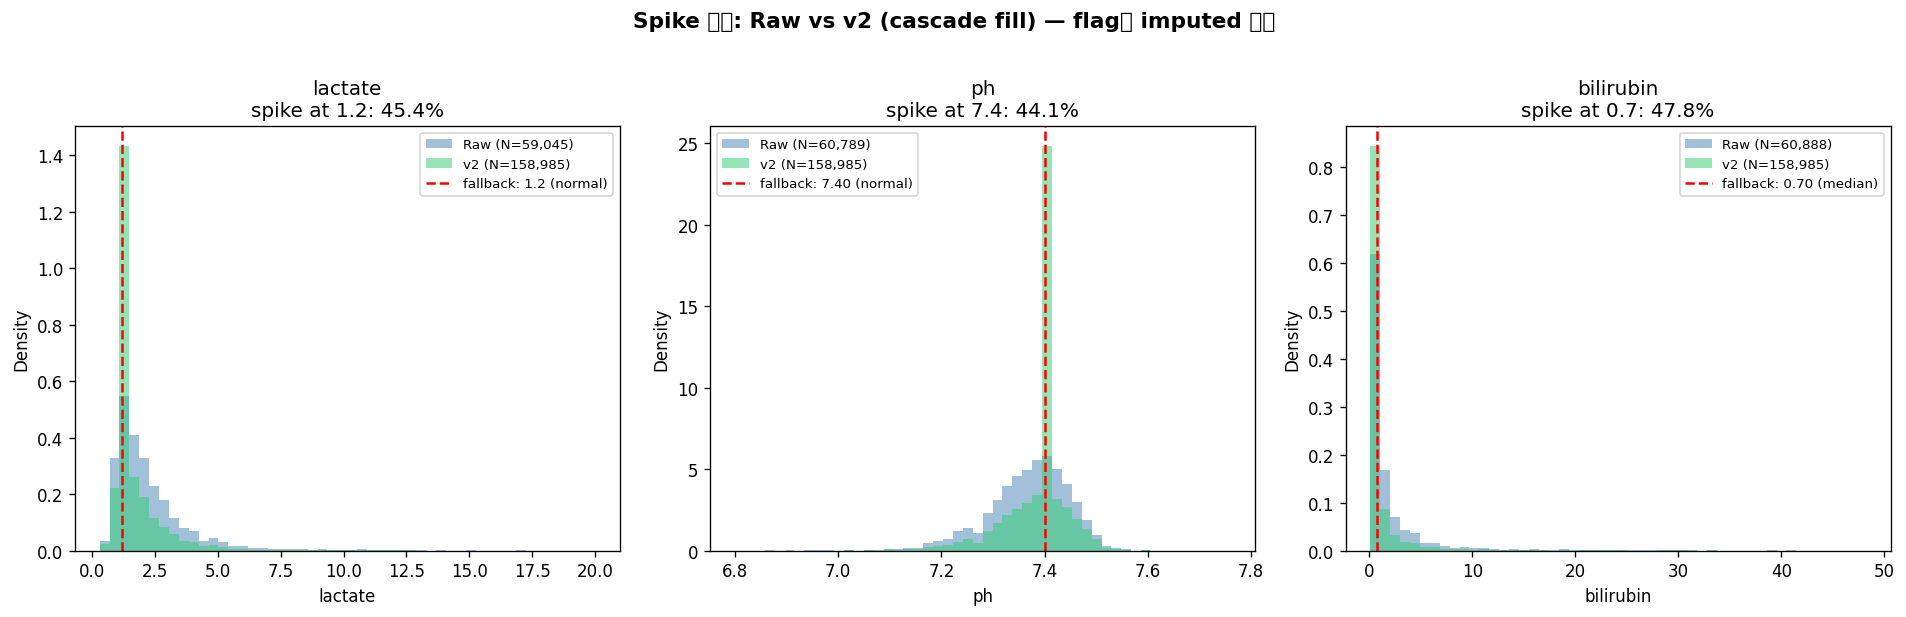


=== Spike 요약 ===
피처               fallback spike      환자med fill                 flag
----------------------------------------------------------------------
lactate                   45.4%         69,104건 lactate_missing: 99,940
ph                        44.1%         66,711건 ph_missing: 98,196
bilirubin                 47.8%         72,883건 bilirubin_missing: 98,097

  → spike 존재하지만 flag이 "이 값은 imputed" 표시 → 모델이 구분 가능


In [17]:
# === Spike 비교: Raw vs v2 (cascade fill) ===

spike_targets = {
    'lactate':   {'fill_val': 1.2,  'label': '1.2 (normal)'},
    'ph':        {'fill_val': 7.40, 'label': '7.40 (normal)'},
    'bilirubin': {'fill_val': 0.70, 'label': '0.70 (median)'},
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, (col, info) in enumerate(spike_targets.items()):
    ax = axes[i]
    fill_val = info['fill_val']
    
    # Raw (결측 제외)
    raw_vals = df_raw[col].dropna()
    # v2 (전부 fill됨)
    v2_vals = df[col]
    
    bins = 50
    ax.hist(raw_vals, bins=bins, alpha=0.5, density=True, label=f'Raw (N={len(raw_vals):,})', color='steelblue')
    ax.hist(v2_vals, bins=bins, alpha=0.5, density=True, label=f'v2 (N={len(v2_vals):,})', color='#2ecc71')
    ax.axvline(fill_val, color='red', linestyle='--', linewidth=1.5, label=f'fallback: {info["label"]}')
    
    # spike at fill constant
    v2_spike = (v2_vals == fill_val).sum()
    v2_spike_pct = v2_spike / len(v2_vals) * 100
    
    ax.set_title(f'{col}\nspike at {fill_val}: {v2_spike_pct:.1f}%')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.suptitle('Spike 확인: Raw vs v2 (cascade fill) — flag이 imputed 구분',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 수치
print('\n=== Spike 요약 ===')
print(f'{"피처":<15} {"fallback spike":>15} {"환자med fill":>15} {"flag":>20}')
print('-' * 70)
for col, info in spike_targets.items():
    fill_val = info['fill_val']
    spike_at_const = (df[col] == fill_val).sum()
    spike_pct = spike_at_const / len(df) * 100
    
    # 원본에서도 해당 값이었던 건수 (진짜 그 값인 환자)
    raw_at_const = (df_raw[col] == fill_val).sum()
    imputed_spike = spike_at_const - raw_at_const
    
    flag_name = {'lactate': 'lactate_missing', 'ph': 'ph_missing', 'bilirubin': 'bilirubin_missing'}[col]
    flag_ones = (df[flag_name] == 1).sum()
    
    print(f'{col:<15} {spike_pct:>14.1f}% {imputed_spike:>14,}건 {flag_name}: {flag_ones:,}')

print('\n  → spike 존재하지만 flag이 \"이 값은 imputed\" 표시 → 모델이 구분 가능')

### EDA 2: Event/Non-event 분포 (v2)

In [18]:
# === v2에서 Event/Non-event 분포 ===
# NaN 유지로 gap 왜곡이 제거되었는지 확인

TARGET = 'composite_next_24h'
compare_cols = ['hr', 'lactate', 'ph', 'creatinine', 'urine_ml_6h', 'gcs_total']

print('=== Event/Non-event Mean 비교 (Raw vs v2) ===')
print(f'{"피처":<18} {"Raw Gap":>10} {"v2 Gap":>10} {"Gap 유지율":>10} {"판정":<8}')
print('-' * 60)

for col in compare_cols:
    if col not in df.columns or col not in df_raw.columns:
        continue
    
    # Raw (결측 제외)
    raw_e = df_raw.loc[(df_raw[TARGET]==1) & df_raw[col].notna(), col].mean()
    raw_ne = df_raw.loc[(df_raw[TARGET]==0) & df_raw[col].notna(), col].mean()
    raw_gap = raw_e - raw_ne
    
    # v2 (NaN 유지 피처는 결측 제외하고 비교)
    v2_e = df.loc[(df[TARGET]==1) & df[col].notna(), col].mean()
    v2_ne = df.loc[(df[TARGET]==0) & df[col].notna(), col].mean()
    v2_gap = v2_e - v2_ne
    
    retention = v2_gap / raw_gap * 100 if raw_gap != 0 else 100
    verdict = 'GOOD' if abs(retention) > 80 else 'OK' if abs(retention) > 50 else 'CONCERN'
    
    print(f'{col:<18} {raw_gap:>+10.3f} {v2_gap:>+10.3f} {retention:>9.1f}% {verdict:<8}')

print('\n[해석]')
print('  - NaN 유지 피처(lactate, ph): Gap 유지율 ~100% (왜곡 없음)')
print('  - Filled 피처(hr, creatinine 등): 저결측이라 Gap 유지율 높음')

=== Event/Non-event Mean 비교 (Raw vs v2) ===
피처                    Raw Gap     v2 Gap    Gap 유지율 판정      
------------------------------------------------------------
hr                     +4.244     +4.132      97.4% GOOD    
lactate                +0.530     +0.554     104.6% GOOD    
ph                     -0.025     -0.027     106.5% GOOD    
creatinine             +0.153     +0.128      83.5% GOOD    
urine_ml_6h           -79.772    -61.897      77.6% OK      
gcs_total              -0.914     -0.937     102.6% GOOD    

[해석]
  - NaN 유지 피처(lactate, ph): Gap 유지율 ~100% (왜곡 없음)
  - Filled 피처(hr, creatinine 등): 저결측이라 Gap 유지율 높음


### EDA 3: 임상 범위 + MNAR 검증

In [19]:
# === 임상 범위 확인 ===
print('=== 임상적 이상값 범위 확인 ===')

clinical_ranges = {
    'hr': (20, 250), 'rr': (4, 60), 'spo2': (40, 100),
    'sbp': (30, 300), 'dbp': (10, 200), 'mbp': (20, 200),
    'temp': (30, 43), 'creatinine': (0.1, 25), 'wbc': (0.1, 150),
    'platelets': (1, 1500), 'potassium': (1.5, 10), 'sodium': (100, 180),
    'lactate': (0.1, 30), 'ph': (6.5, 8.0), 'bilirubin': (0.1, 60),
    'gcs_total': (3, 15), 'urine_ml_6h': (0, 10000),
}

total_oor = 0
for col, (lo, hi) in clinical_ranges.items():
    if col not in df.columns:
        continue
    oor = ((df[col] < lo) | (df[col] > hi)).sum()
    total_oor += oor
    if oor > 0:
        print(f'  {col}: {oor}건 범위외 (min={df[col].min():.2f}, max={df[col].max():.2f})')

if total_oor == 0:
    print('  PASS: 모든 피처 임상 범위 내')

# === MNAR 검증 (ph_missing 추가) ===
TARGET = 'composite_next_24h'
print(f'\n=== Missing Flag ↔ Event Rate ({TARGET}) ===')

flags = {
    'lactate_missing':   ('미측정=경증',     False),
    'abga_checked':      ('시행=중증',       True),
    'ph_missing':        ('미측정=경증',     False),   # NEW
    'bilirubin_missing': ('미측정=경증',     False),
    'urine_missing':     ('미모니터링=경증', False),
}

print(f'{"Flag":<22} {"0 rate":>8} {"1 rate":>8} {"MNAR":>15} {"판정":<8}')
print('-' * 65)

for flag, (desc, higher_is_severe) in flags.items():
    if flag not in df.columns:
        continue
    rate_0 = df.loc[df[flag]==0, TARGET].mean() * 100
    rate_1 = df.loc[df[flag]==1, TARGET].mean() * 100
    
    if higher_is_severe:
        ok = rate_1 > rate_0
    else:
        ok = rate_1 < rate_0
    
    verdict = 'CONFIRM' if ok else 'REJECT'
    marker = ' ← NEW' if flag == 'ph_missing' else ''
    print(f'{flag:<22} {rate_0:>7.2f}% {rate_1:>7.2f}% {desc:>15} {verdict:<8}{marker}')

=== 임상적 이상값 범위 확인 ===
  gcs_total: 86건 범위외 (min=1.00, max=15.00)

=== Missing Flag ↔ Event Rate (composite_next_24h) ===
Flag                     0 rate   1 rate            MNAR 판정      
-----------------------------------------------------------------
lactate_missing          12.08%    5.87%          미측정=경증 CONFIRM 
abga_checked              5.42%   12.55%           시행=중증 CONFIRM 
ph_missing               12.55%    5.47%          미측정=경증 CONFIRM  ← NEW
bilirubin_missing        10.00%    7.04%          미측정=경증 CONFIRM 
urine_missing             7.88%    9.52%        미모니터링=경증 REJECT  


### EDA 4: v1 vs v2 기술통계 비교

In [20]:
# === v1(09) vs v2(09-1) 기술통계 비교 ===
# v1의 경우 09를 다시 실행하지 않고, 09 출력물이 있으면 로드

v1_path = INPUT_DIR / "preprocessed.csv"
if os.path.exists(v1_path):
    df_v1 = pd.read_csv(v1_path, nrows=5)  # 컬럼 확인만
    df_v1 = pd.read_csv(v1_path)
    
    compare_features = ['lactate', 'ph', 'bilirubin', 'temp', 'creatinine']
    
    print('=== v1 vs v2 기술통계 비교 (핵심 변경 피처) ===')
    for col in compare_features:
        if col not in df_v1.columns or col not in df.columns:
            continue
        
        v1_desc = df_v1[col].describe()
        v2_desc = df[col].describe()
        
        print(f'\n--- {col} ---')
        print(f'{"":>10} {"v1 (09)":>12} {"v2 (09-1)":>12} {"차이":>12}')
        for stat in ['mean', 'std', '25%', '50%', '75%']:
            v1_val = v1_desc[stat]
            v2_val = v2_desc[stat]
            diff = v2_val - v1_val
            print(f'{stat:>10} {v1_val:>12.3f} {v2_val:>12.3f} {diff:>+12.3f}')
        
        # v2 NaN 수
        v2_na = df[col].isna().sum()
        print(f'{"NaN":>10} {"0":>12} {v2_na:>12,}')
else:
    print('preprocessed.csv (v1) 없음 — 09 실행 후 비교 가능')
    
    # v2 자체 기술통계
    print('\n=== v2 기술통계 (핵심 피처) ===')
    stats_cols = ['hr', 'lactate', 'ph', 'bilirubin', 'creatinine', 'temp', 'gcs_total', 'urine_ml_6h']
    existing = [c for c in stats_cols if c in df.columns]
    print(df[existing].describe().round(3))

=== v1 vs v2 기술통계 비교 (핵심 변경 피처) ===

--- lactate ---
                v1 (09)    v2 (09-1)           차이
      mean        1.624        1.687       +0.063
       std        1.153        1.194       +0.041
       25%        1.200        1.200       +0.000
       50%        1.200        1.200       +0.000
       75%        1.600        1.800       +0.200
       NaN            0            0

--- ph ---
                v1 (09)    v2 (09-1)           차이
      mean        7.388        7.387       -0.001
       std        0.055        0.061       +0.006
       25%        7.390        7.370       -0.020
       50%        7.400        7.400       +0.000
       75%        7.400        7.400       +0.000
       NaN            0            0

--- bilirubin ---
                v1 (09)    v2 (09-1)           차이
      mean        1.307        1.344       +0.037
       std        2.827        2.911       +0.084
       25%        0.700        0.600       -0.100
       50%        0.700        0.700      

In [21]:
print('\n' + '=' * 60)
print('=== 09-1. Preprocessing v2 완료 ===')
print('=' * 60)

print(f'\n샘플: {len(df):,}개 / 환자: {df["stay_id"].nunique():,}명')
print(f'컬럼: {len(df.columns)}개 (09 대비 +1: ph_missing)')
print(f'NaN: 0건 (전부 fill)')

print(f'\n=== 09 → 09-1 변경 요약 ===')
print(f'  1. ph_missing 플래그 추가 (abga_checked과 별도로 ph 결측 독립 표시)')
print(f'  2. 환자 median cascade: temp/labs/urine/high-missing 모두 적용')
print(f'     FFill → 환자 median → 정상값/global median')
print(f'  3. Missing flag 5개: 모델이 imputed vs 실측 구분')
print(f'  4. 출력: preprocessed_v2.csv')

print(f'\n다음 단계: 10_feature_engineering.ipynb (preprocessed_v2.csv 사용)')


=== 09-1. Preprocessing v2 완료 ===

샘플: 158,985개 / 환자: 4,713명
컬럼: 58개 (09 대비 +1: ph_missing)
NaN: 0건 (전부 fill)

=== 09 → 09-1 변경 요약 ===
  1. ph_missing 플래그 추가 (abga_checked과 별도로 ph 결측 독립 표시)
  2. 환자 median cascade: temp/labs/urine/high-missing 모두 적용
     FFill → 환자 median → 정상값/global median
  3. Missing flag 5개: 모델이 imputed vs 실측 구분
  4. 출력: preprocessed_v2.csv

다음 단계: 10_feature_engineering.ipynb (preprocessed_v2.csv 사용)
